In [1]:
# Dependencies installieren
%pip install matplotlib scikit-image numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
from matplotlib.pyplot import subplots
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
import math

# Alle Bilder schonmal laden

IMG_PLANE = io.imread('airfield02g.tif')
IMG_PLANE_DETAIL = io.imread('airfield02g-detail.tif')
IMG_CORNER_TEST = io.imread('corner-test.tif')
IMG_NOISY_LINES = io.imread('noisy-lines.tif')
IMG_DISK_BLUR = io.imread('Fig0503.tif')
IMG_IRELAND = io.imread('ireland02-orig.tif')

# Sobel

Die Hough Transformation wird auf ein Kantenbild angewendet, somit müssen wir bevor wir die Transformation durchführen können den Sobel Operator implementieren. Auf das Kantenbild wird dann noch mit einem Threshold ein Binäres Bild erzeugt (Keine Graustufenwerte sondern nurnoch true/false Werte für jeden Pixel, ob der Pixel eine Kante ist oder nicht)

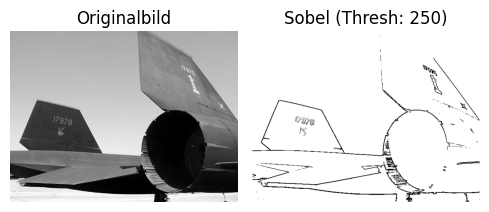

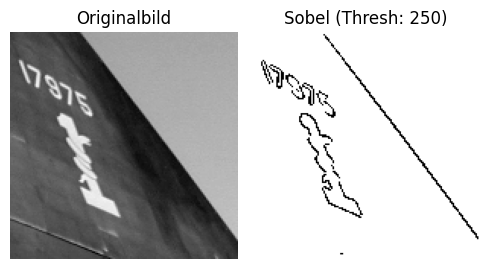

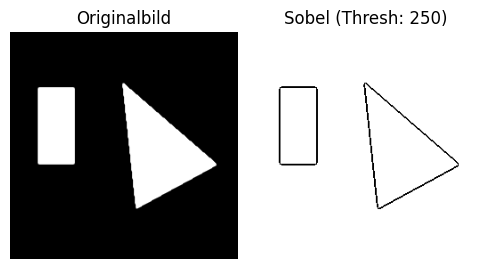

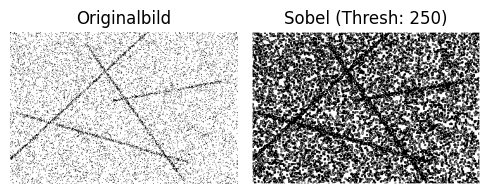

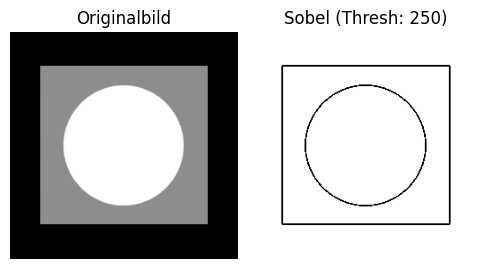

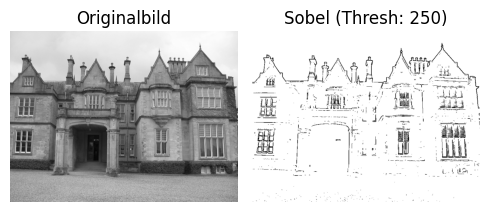

In [3]:
# Sobel Implementierung

S_X = np.array(
    [[1.0, 0.0, -1.0],
    [2.0, 0.0, -2.0],
    [1.0, 0.0, -1.0]]
)

S_Y = np.array(
    [[1.0, 2.0, 1.0],
    [0.0, 0.0, 0.0],
    [-1.0, -2.0, -1.0]]
)

def sobel(img):
    [height, width] = np.shape(img)
    img_filtered = np.zeros(shape=(height, width)) 

    for y in range(height - 2):
        for x in range(width - 2):
            x_m = np.sum(np.multiply(S_X, img[y:y + 3, x:x + 3]))
            y_m = np.sum(np.multiply(S_Y, img[y:y + 3, x:x + 3]))
            img_filtered[y + 1, x + 1] = np.sqrt(x_m ** 2 + y_m ** 2)

    return img_filtered

def sobel_thresh(img, thresh):
    img_sobel = sobel(img)
    img_thresh = img_sobel > thresh
    return img_thresh.astype(float)

def plotS(img, thresh):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 3))

    ax1.imshow(img, cmap='gray')
    ax1.set_title('Originalbild')
    ax1.axis('off')

    res = sobel_thresh(img, thresh)
    ax2.imshow(res, cmap='gray_r')
    ax2.set_title(f'Sobel (Thresh: {thresh})')
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

EDGE_THRESH = 250

plotS(IMG_PLANE, EDGE_THRESH)
plotS(IMG_PLANE_DETAIL, EDGE_THRESH)
plotS(IMG_CORNER_TEST, EDGE_THRESH)
plotS(IMG_NOISY_LINES, EDGE_THRESH)
plotS(IMG_DISK_BLUR, EDGE_THRESH)
plotS(IMG_IRELAND, EDGE_THRESH)

# Hough Transformation

Bei der Hough Transformation wird ein diskreter Punkt vom 2D Bildraum in den Parameterraum Transformiert (in der Hesschen Normalform). Für den Punkt werden dann im Parameterraum alle möglichen Geraden berechnet die durch den Punkt (X, Y) gehen (in verschieden hoher Auflösung **angle_steps**) und im 2D Hough Akkumulator werden dann alle Winkel und Radien gespeichert. Das macht mann dan für alle Punkte. Punkte welche auf derselben Gerade liegen bilden Sinuswellen die sich schneiden/hotspots bilden, an diesen Hotspots ist dann eine Gerade zu Vermuten. Um zu entscheiden welche Linien im Hough Akkumulator ernsthaft zu betrachten sind, wird mit einem Threshhold gesteuert ab welcher Hotspotstärke eine Linie als Linie gilt (Desto höher der Wert desto länger ist die Linie => Mehr Sinuswellen die sich überlagern in verschiedenen Punkten)


In [4]:
### Hough Implementierung

class LinearHT:
    
    def __init__(self, edges_img, angle_steps, radius_steps):
        
        self.edges_img = edges_img

        [height, width] = np.shape(edges_img)

        self.img_height = height
        self.img_width = width

        self.x_cen = width / 2
        self.y_cen = height / 2

        self.angle_steps = angle_steps
        self.angle_step = np.pi / angle_steps
        
        self.radius_steps = radius_steps
        r_max = np.sqrt(self.x_cen * self.x_cen + self.y_cen * self.y_cen) 
        self.radius_step = 2 * r_max / radius_steps
 
    def calculatePixel(self, u, v, h):

        x = u - self.x_cen
        y = v - self.y_cen

        for a in range(self.angle_steps):
            theta = a * self.angle_step
            r = int(((x * np.cos(theta) + y * np.sin(theta)) / self.radius_step) + self.radius_steps / 2)
            if r >= 0 and r < self.radius_steps:
                h[r][a] = h[r][a] + 1
            
    def accumulate(self):
        
        houghAcc = np.zeros(shape=(self.radius_steps, self.angle_steps))

        for y in range(self.img_height):
            for x in range(self.img_width):
                if self.edges_img[y][x]:
                    self.calculatePixel(x, y, houghAcc)

        return houghAcc

    # Für Darstellungszwecke
    def accumulateSingle(self):
        houghAcc = np.zeros(shape=(self.radius_steps, self.angle_steps))

        for y in range(self.img_height):
            for x in range(self.img_width):
                if self.edges_img[y][x]:
                    self.calculatePixel(x, y, houghAcc)
                    return houghAcc

## Darstellung eines einzigen Punktes im Akkumulator

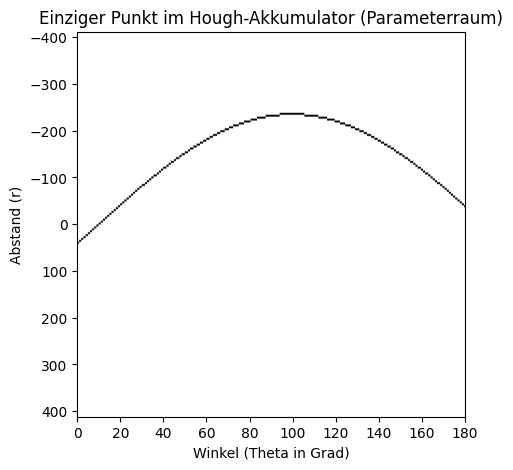

In [5]:
def plotHTASingle(img, edge_threshold, angle_steps, radius_steps):
    houghArr = LinearHT(sobel_thresh(img, edge_threshold), angle_steps, radius_steps).accumulateSingle()
    [height, width] = np.shape(houghArr)
    max_r = np.sqrt(np.pow(width, 2) + np.pow(height, 2))
    
    plt.figure(figsize=(5, 5))
    plt.imshow(houghArr, cmap='Greys', extent=[0, 180, max_r, -max_r], aspect='auto')
    
    plt.title('Einziger Punkt im Hough-Akkumulator (Parameterraum)')
    plt.xlabel('Winkel (Theta in Grad)')
    plt.ylabel('Abstand (r)')
    plt.show()

plotHTASingle(IMG_PLANE, 250, 360, 200)

## Darstellung Hough Akkumulator

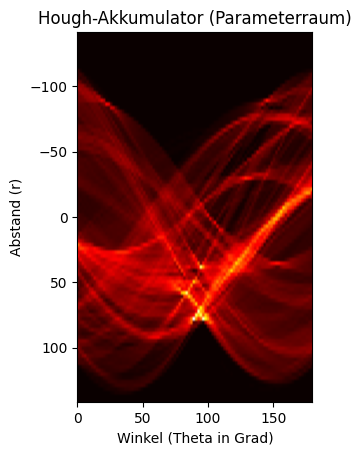

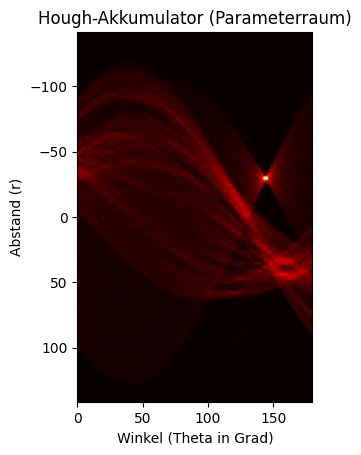

In [6]:
def plotHTA(img, edge_threshold, angle_steps, radius_steps):
    
    houghArr = LinearHT(sobel_thresh(img, edge_threshold), angle_steps, radius_steps).accumulate()
    [height, width] = np.shape(houghArr)
    max_r = np.sqrt(np.pow(width, 2) + np.pow(height, 2))
    
    plt.imshow(houghArr, cmap='hot', extent=[0, 180, max_r, -max_r])
    plt.title('Hough-Akkumulator (Parameterraum)')
    plt.xlabel('Winkel (Theta in Grad)')
    plt.ylabel('Abstand (r)')
    plt.show()

# Gucken ob wir schöne Sinuswellen sehen die sich miteinander Schneiden (Heiße Stellen = erkannte Kannte)
plotHTA(IMG_PLANE, EDGE_THRESH, 100, 100)
plotHTA(IMG_PLANE_DETAIL, EDGE_THRESH, 100, 100) 

# Darstellung erkannter geraden im Bild

Wenn wir ein Threshhold wählen um den Hough Akkumulator auszuwerten, können wir definieren ab wann ein Hotspot als Kante gewertet wird. Je nach Komplexität des Bildes und Rauschen im Bild ist ein niedrigerer oder höherer Schwellenwert zu wählen, bei vielem Rauschen oder bei komplexeren Features im Bild wird sonst zu viel als Kante erkannt

Nach der Berechnung können wir die Hotspots aus dem Array zurückrechnen und wieder als Gerade im Bild darstellen (einfach als Gerade die über das Bild hinausgeht, wir haben keine Information darüber wie Lang die Kante ist)

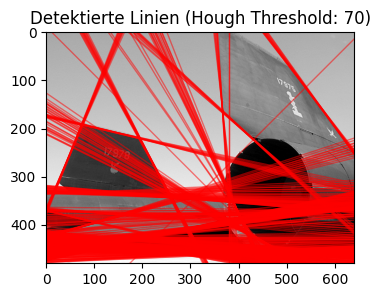

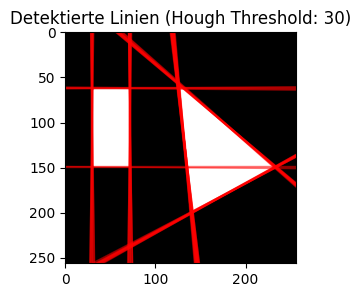

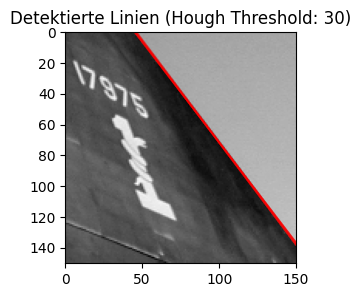

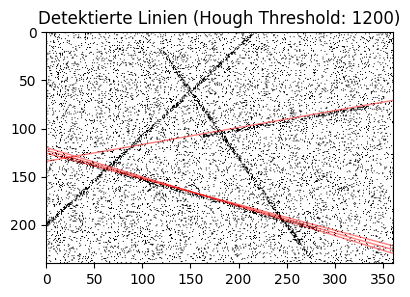

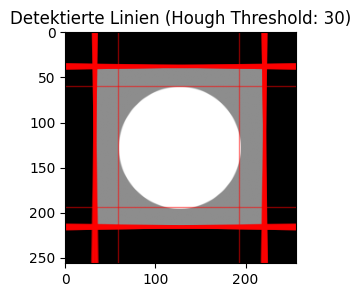

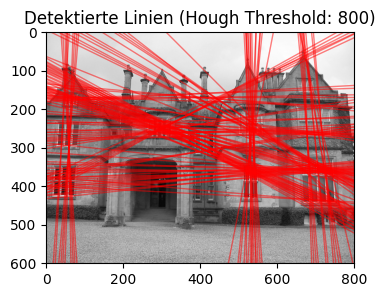

In [7]:
def overlayHT(img, edge_threshold, angle_steps, radius_steps, hough_threshold=50):
    
    edges = sobel_thresh(img, edge_threshold)
    ht = LinearHT(edges, angle_steps, radius_steps)
    houghAcc = ht.accumulate()

    plt.figure(figsize=(5, 3))
    plt.imshow(img, cmap='gray')
    
    for r_idx in range(radius_steps):
        for a_idx in range(angle_steps):
            votes = houghAcc[r_idx][a_idx]
            
            if votes > hough_threshold:
                theta = a_idx * ht.angle_step
                r = (r_idx - radius_steps / 2) * ht.radius_step
                
                a = np.cos(theta)
                b = np.sin(theta)
                x0 = a * r + ht.x_cen
                y0 = b * r + ht.y_cen
                
                x1 = int(x0 + 1000 * (-b))
                y1 = int(y0 + 1000 * (a))
                x2 = int(x0 - 1000 * (-b))
                y2 = int(y0 - 1000 * (a))
                
                plt.plot([x1, x2], [y1, y2], color='red', linewidth=1, alpha=0.5)

    plt.title(f'Detektierte Linien (Hough Threshold: {hough_threshold})')
    plt.xlim(0, img.shape[1])
    plt.ylim(img.shape[0], 0) # Y-Achse invertiert für Bildkoordinaten
    plt.show()

overlayHT(IMG_PLANE, EDGE_THRESH, 360, 1000, 70)
overlayHT(IMG_CORNER_TEST, EDGE_THRESH, 360, 1000, 30)
overlayHT(IMG_PLANE_DETAIL, EDGE_THRESH, 360, 1000, 30)
overlayHT(IMG_NOISY_LINES, EDGE_THRESH, 180, 100, 1200)
overlayHT(IMG_DISK_BLUR, EDGE_THRESH, 360, 1000, 30)
overlayHT(IMG_IRELAND, EDGE_THRESH, 180, 100, 800)

# Fragen

a) **Wie konnen die Kanten im ursprünglichem Bild mit dieser Schwellwertoperation
ermittelt werden**

Die Hotspots im Outputbild nach der Schwellenwertoperation markieren gewisse Radius/Winkelkombinationen im Parameterraum als zugehörig zu einer Linie im ursp. Bild. Wenn man die Werte wieder in die Hessche Normalform einsetzt lässt sich eine Gerade im Bild über die erkannte Kante legen

b) **Welches sind die dominierendsten (längsten) Kanten?**

Die höchsten Werte im Hough Akkumulator sind die längsten Kanten, weil dort am meisten Punkte gevotet haben

c) **Anstelle der Schwellwertoperation könnte auch die Methode der Non-MaximumSuppression verwendet werden, um die Punkte im HoughArray detektieren zuköonnen. Beschreiben Sie diese Methode kur**

Das Problem bei der Schwellenwertoperation ist, das benachbarte Punkte oft auch über dem Schwellenwert liegen im Akkumulator. Das sorgt dafür das wenn diese Punkte über dem Schwellenwert liegen, für eine Kante mehrere leicht verschobene Linien detektiert werden.

Bei der Non-Maximum-Suppression wird die lokale Nachbarschaft im Akkumulator auch geprüft (3x3 Fenster z. B.) und ein Wert bleibt nur erhalten wenn er höher ist als seine Nachbarn im Fenster, somit werden alle ähnlichen Werte unterdrückt die niedriger sind als der absolute Hotspot
?
